<h1>Project 1: Data Analysis Project<h1>

<h2> 1 Inequality in Denmark

### 1.1 The Gini coefficient and the top 10 percent share

In [1]:
# %pip install --upgrade git+https://github.com/alemartinello/dstapi
# %pip install --upgrade fredapi

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dstapi import DstApi
import pandas as pd

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})


In [3]:
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en') #change language


Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [4]:
params = {
    'table': 'IFOR41',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

ginidk = IFOR41.get_data(params=params)
ginidk.head(5)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


In [5]:
ginidk=ginidk.drop(columns=['ULLIG','KOMMUNEDK'])
ginidk = ginidk.rename(columns={'INDHOLD':'gini', 'TID': 'year'})
ginidk= ginidk.set_index('year').sort_index()

ginidk.head(5)

,gini
year,
1987,22.07
1988,22.06
1989,21.93
1990,22.16
1991,21.99


Text(0, 0.5, 'Gini')

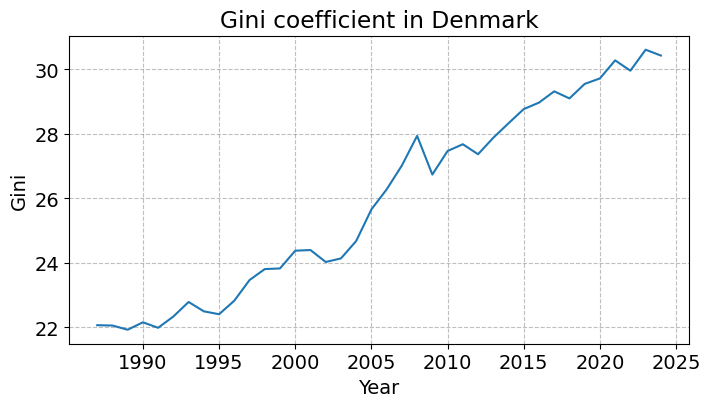

In [6]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot()
ax.plot(ginidk.index,ginidk['gini'].astype(float))
ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini')

In [7]:
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [8]:
params = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

df = IFOR32.get_data(params=params)
df.head(10)
df.tail(10)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
370,First decil,All Denmark,2001,62629
371,Second decil,All Denmark,2001,98552
372,Third decil,All Denmark,2001,114430
373,Fourth decil,All Denmark,2001,129885
374,Fifth decil,All Denmark,2001,144273
375,Sixth decil,All Denmark,2001,158392
376,Seventh decil,All Denmark,2001,173884
377,Eigth decil,All Denmark,2001,193021
378,Ninth decil,All Denmark,2001,221638
379,Tenth decil,All Denmark,2001,338942


In [9]:
df=df.drop(columns=['KOMMUNEDK'])
df = df.rename(columns={'INDHOLD':'income', 'TID': 'year'})
df= df.set_index('year').sort_index()

df.head(5)

,DECILGEN,income
year,,
1987,First decil,31418
1987,Ninth decil,123582
1987,Eigth decil,110184
1987,Seventh decil,100691
1987,Sixth decil,92777


<Axes: title={'center': 'Top 10% income share in Denmark'}, xlabel='Year', ylabel='Share of total income'>

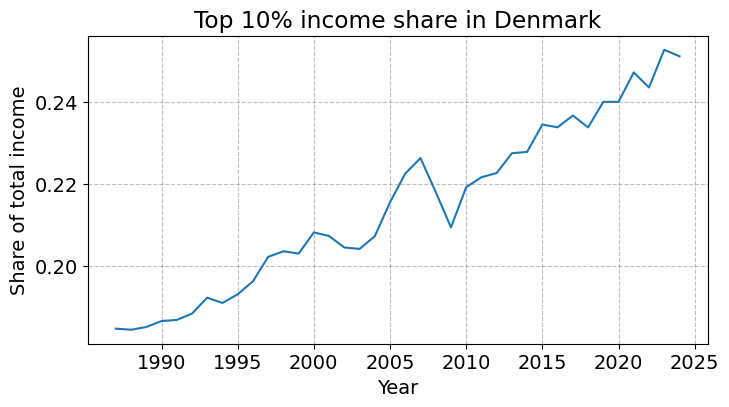

In [10]:
pivot = df.pivot_table(values='income', index=df.index, columns='DECILGEN', aggfunc='sum')
top10_share = pivot['Tenth decil'] / pivot.sum(axis=1)

top10_share.plot(title='Top 10% income share in Denmark', ylabel='Share of total income', xlabel='Year', figsize=(8,4))

#### Describe how inequality in Denmark has developed since 1987. Do the two measures tell the same story? 

Both graphs show gradually increasing inequality from 1987 to 2000, a slight dip from 2000 to ~2003 followed by a sharp spike that peaked immediately before the financial crisis and sharply fell during it, before continuing on its previous trend of gradually increasing from 2010-2024.


In [11]:
#Compute the correlation between them over time
print(np.corrcoef(ginidk['gini'].astype(float), top10_share)[0,1])

0.9816415450527721


### 1.2 Prediction

In [12]:
# Importing the packages

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [13]:
# Settting up the code for the prediction

y=ginidk['gini'].astype(float).values
t=ginidk.index.astype(int).values-1987

S1= lambda beta: sum((y-(beta[0]+beta[1]*t))**2)
S2= lambda beta: sum((y-(beta[0]+beta[1]*t+beta[2]*t**2))**2)

In [14]:
# Solving the minimization problem

minproblin = minimize(S1, x0=(0,0),constraints=None)
minprobqua = minimize(S2, x0=(0,0,0),constraints=None)

beta0_lin, beta1_lin = minproblin.x
beta0_quad, beta1_quad,beta2_quad = minprobqua.x

print('Beta linear=', beta0_lin, beta1_lin)
print('Beta quadratic=', beta0_quad, beta1_quad, beta2_quad)

Beta linear= 21.042753545648125 0.26354959467635763
Beta quadratic= 21.304186697307134 0.21997579816762736 0.0011776761712922607


In [15]:
# Checking our answers against np.polyfit

coeff_lin= np.polyfit(t,y,1)
print(coeff_lin)

coeff_quad=np.polyfit(t,y,2)
print(coeff_quad)

[ 0.26354962 21.04275304]
[1.17769085e-03 2.19975061e-01 2.13042004e+01]


When looking at the minimization an the np.polyfit against eachother they both return the same coefficient. This indicate that we have done the minimization problem correct.

Text(0, 0.5, 'Gini')

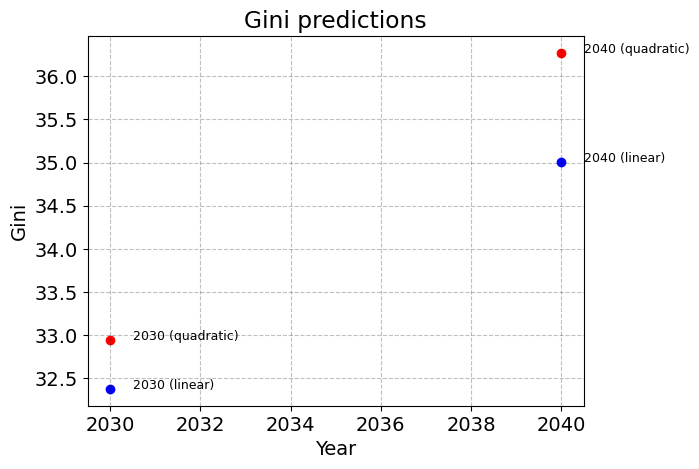

In [16]:
# Predicting an plotting the Gini coefficient in 2030 and 2040

t2030 = 2030-1987
t2040 = 2040-1987

# To find y we set y to the formula p1 and p2 because the difference 
# bewteen them should be 0 if the formula is correctly minimized

lin_gin2030 = beta0_lin + beta1_lin * t2030
lin_gin2040 = beta0_lin + beta1_lin * t2040
quad_gin2030 = beta0_quad + beta1_quad * t2030 + beta2_quad * t2030**2
quad_gin2040 = beta0_quad + beta1_quad * t2040 + beta2_quad * t2040**2

plt.scatter(2030, lin_gin2030, color='blue')
plt.text(2030 + 0.5, lin_gin2030 + 0.001, '2030 (linear)', fontsize=9)

plt.scatter(2040, lin_gin2040, color='blue')
plt.text(2040 + 0.5, lin_gin2040 + 0.001, '2040 (linear)', fontsize=9)

plt.scatter(2030, quad_gin2030, color='red')
plt.text(2030 + 0.5, quad_gin2030 + 0.001, '2030 (quadratic)', fontsize=9)


plt.scatter(2040, quad_gin2040, color='red')
plt.text(2040 + 0.5, quad_gin2040 + 0.001, '2040 (quadratic)', fontsize=9)

plt.title('Gini predictions')
plt.xlabel('Year')
plt.ylabel('Gini')

The plot shows linear and quadratic predictions of the Gini coefficient for 20230 and 2040. In 2030 we see that the two differ around 1,2 in the prediction of the Gini coeffeicient. In 2040 there is a bigger difference between the linear and quadratic gini prediction, around 2,5.The quadratic model has the highest prediction of the Gini coefficient both in 2030 and 2040. This shows that the predictions rely highly on the choice of model. The gini coefficient in Denmark has increased in the last centuries. Therefore, its easy to believe that this development in gini will continue. However, I would not trust the model to predict the gini coefficient, as they are both simple models based on the trend and doesnt include the factors which actually drives the change in the gini coeffiecient such as policy, enplyment and demographics.

### 1.3 Municipalities

#### 1.3.1

In [17]:
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [18]:
# Gini across municipalities

params_muni_gini = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

municip_gini = IFOR41.get_data(params=params_muni_gini)
municip_gini.head(5)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,Copenhagen,2016,33.24
2,Gini coefficient,Frederiksberg,2016,34.85
3,Gini coefficient,Ballerup,2016,25.77
4,Gini coefficient,Brøndby,2016,25.71


In [19]:
# Clearing the data

municip_gini = municip_gini.drop(columns = ['ULLIG'])
municip_gini = municip_gini.rename(columns = {'INDHOLD':'gini', 'TID': 'year','KOMMUNEDK': 'municipalities'})
municip_gini =municip_gini.set_index('year').sort_index()

display(municip_gini)

,municipalities,gini
year,,
1987,Hjørring,21.96
1987,Greve,18.64
1987,Køge,19.52
1987,Halsnæs,18.50
1987,Roskilde,20.54
...,...,...
2024,Greve,26.35
2024,Frederikssund,26.11
2024,Egedal,23.85


In [20]:
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [21]:
# Top 10% share across municipalities

params_muni_top10 = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

municip_top10 = IFOR32.get_data(params=params_muni_top10)
municip_top10.head(5)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,Second decil,Odense,2013,123841
1,Third decil,Odense,2013,150153
2,Fourth decil,Odense,2013,170790
3,Fifth decil,Odense,2013,193979
4,Sixth decil,Odense,2013,218942


In [22]:
# Cleaning the data

municip_top10 = municip_top10.rename(columns = {'INDHOLD':'income', 'TID': 'year','KOMMUNEDK': 'municipalities'})
municip_top10 =municip_top10.set_index('year').sort_index()

display(municip_top10)

,DECILGEN,municipalities,income
year,,,
1987,Sixth decil,Bornholm,85526
1987,First decil,Frederikshavn,32887
1987,Second decil,Frederikshavn,59922
1987,Third decil,Frederikshavn,68777
1987,Fourth decil,Frederikshavn,76841
...,...,...,...
2024,Third decil,Faaborg-Midtfyn,213520
2024,Third decil,Kerteminde,212744
2024,Third decil,Nyborg,209481


In [23]:
# Making a pivot table

municip_top10_reset = municip_top10.reset_index()

pivot_muni = municip_top10_reset.pivot_table(
        values = 'income',
        index = ['year', 'municipalities'],
        columns = 'DECILGEN',
        aggfunc = 'sum'
)


municip_top10_share = pivot_muni['Tenth decil'] / pivot_muni.sum(axis=1)

display(municip_top10_share)

year  municipalities 
1987  Aabenraa           0.183458
      Aalborg            0.178168
      Aarhus             0.184060
      Albertslund        0.167352
      All Denmark        0.184549
                           ...   
2024  Vejle              0.233658
      Vesthimmerlands    0.226623
      Viborg             0.222808
      Vordingborg        0.216030
      Ærø                0.219151
Length: 3762, dtype: float64

In [24]:
# Merging the two tables

combined = pd.merge(
        municip_gini.reset_index(),
        municip_top10_share.reset_index(name='top10_share'),
        on= ['year', 'municipalities'],
        how= 'inner'
)

combined =combined.sort_values(['municipalities','year']).reset_index(drop=True)

display(combined)

,year,municipalities,gini,top10_share
0,1987,Aabenraa,21.33,0.183458
1,1988,Aabenraa,21.51,0.182620
2,1989,Aabenraa,20.74,0.181198
3,1990,Aabenraa,20.83,0.182724
4,1991,Aabenraa,20.86,0.185529
...,...,...,...,...
3757,2020,Ærø,25.61,0.208865
3758,2021,Ærø,26.63,0.216633
3759,2022,Ærø,27.02,0.216645
3760,2023,Ærø,27.67,0.219123


In [25]:
# Choosing the types

combined['gini'] = combined['gini'].astype(float)
combined['top10_share'] = combined['top10_share'].astype(float)

In [26]:
# The correlation between the Gini coefficient and top 10% share across municipalities in 2024
combined_2024 = combined[combined['year'] == 2024]

print(np.corrcoef(combined_2024['gini'], combined_2024['top10_share'])[0,1])

0.9747129559226702


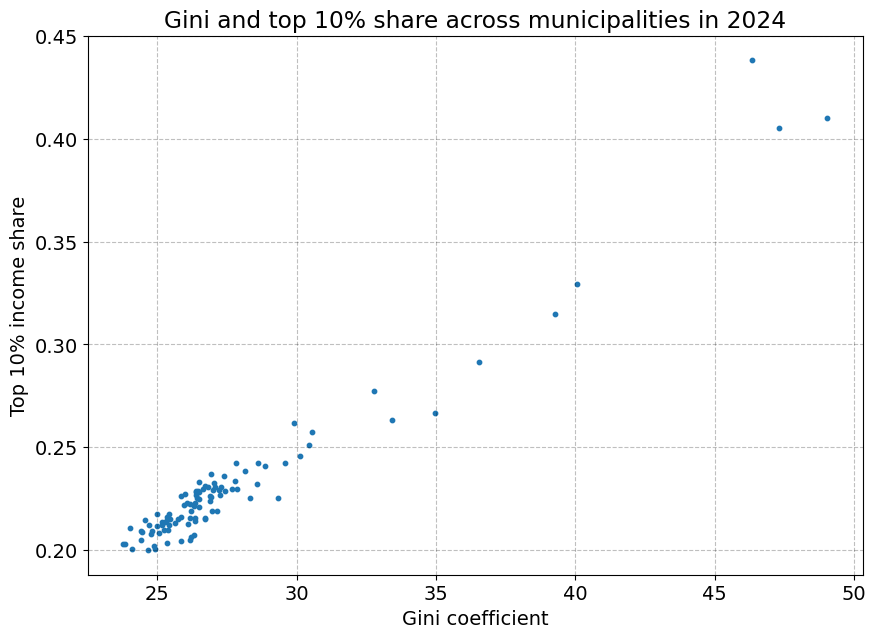

In [27]:
combined_2024 = combined[combined['year'] == 2024]

fig = plt.figure(figsize = (10,7))
ax=fig.add_subplot(1,1,1)
ax.scatter(combined_2024["gini"],combined_2024["top10_share"], s=10)

ax.set_title("Gini and top 10% share across municipalities in 2024")
ax.set_xlabel('Gini coefficient')
ax.set_ylabel('Top 10% income share');

The correlation betwen the Gini coefficient and the top 10% income share across municipalities in 2024 is 0.9747. The correlation bewteen the Gini coefficient and the top 10% income share across municipalities is thus really high. The scatterplot picturing Gini and top 10% share across municipalities in 2024 shows an almost linear relationship between Gini and top 10% income share, without any major outliers. The scatterplot doesn´t show any major outliers in 2024 that could blur the correlation. We see three municipalities a bit separated from the other in the top right of the scatterplot. However, these three municipalities still follows the overall linear relationship. Overall the scatterplot thus visually confirms the correlation between Gini and top 10% income share. The higher the Gini, the higher top 10% income share. 
In task 1.1 we calculated that the correlation between top 10% income share and Denmark´s Gini coefficient during the time period 1987-2024 was 0.9816. The correlation we found across municipalities in 2024 is thus really close to the Denmarks national correlation over time. This could suggest that the high correlation isn´t something specific to 2024. However, the two correlations are computed with different variables and over different times. Therefore this says nothing about if the correlation is equally strong every year.

#### 1.3.2

In [28]:
# Sorting Gini values for 2024
gini_2024 = municip_gini.loc[2024].sort_values('gini')

# Finding the smallest and largest Gini coefficients
smallest_gini = gini_2024[['municipalities', 'gini']].head(10)
largest_gini = gini_2024[['municipalities', 'gini']].tail(10)

print('10 most equal municipalities')
print(smallest_gini)

print('10 most unequal municipalities')
print(largest_gini)

10 most equal municipalities
       municipalities   gini
year                        
2024  Faaborg-Midtfyn  23.77
2024           Egedal  23.85
2024         Bornholm  24.03
2024             Faxe  24.09
2024         Favrskov  24.41
2024          Halsnæs  24.41
2024           Assens  24.46
2024        Hedensted  24.58
2024      Albertslund  24.66
2024            Odder  24.70
10 most unequal municipalities
      municipalities   gini
year                       
2024       Helsingør  30.55
2024     Fredensborg  32.76
2024          Aarhus  33.43
2024      Copenhagen  34.97
2024   Frederiksberg  36.54
2024  Lyngby-Taarbæk  39.28
2024        Hørsholm  40.07
2024           Vejen  46.32
2024       Rudersdal  47.31
2024        Gentofte  49.04


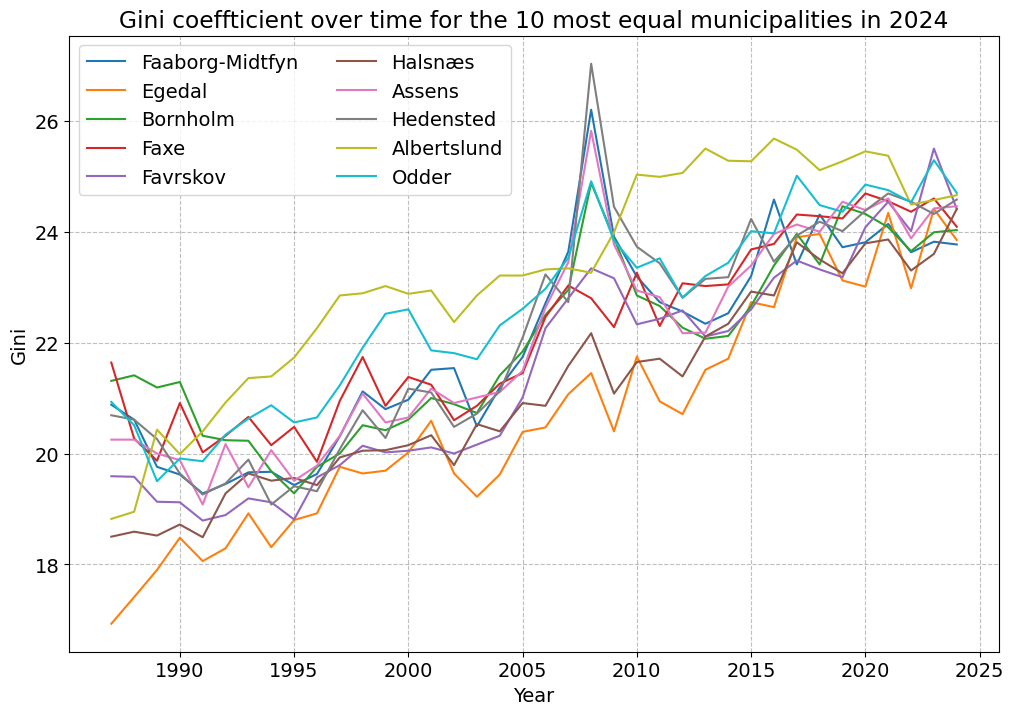

In [29]:
# Plotting the 10 municipalities with the smallest Gini in 2024

most_equal_plot= smallest_gini["municipalities"]

fig, ax = plt.subplots(figsize=(12, 8))
for muni in most_equal_plot:
    series= municip_gini[municip_gini["municipalities"]==muni]["gini"].astype(float)
    ax.plot(series.index, series.values, label=muni)
ax.set_xlabel('Year')
ax.set_ylabel('Gini')
ax.set_title('Gini coeffticient over time for the 10 most equal municipalities in 2024')
ax.legend(ncol=2)
plt.show()

Overall all the municipalities are following the same rising trend. The gini coefficient is spiking and afterwards falling again for most of the municipalities because of the financial crisis in 2008. Albertslund and Faxe are not following this trend. Overall, Albertslund deviates from the general trend but Faxe follows the trend most of the time. 

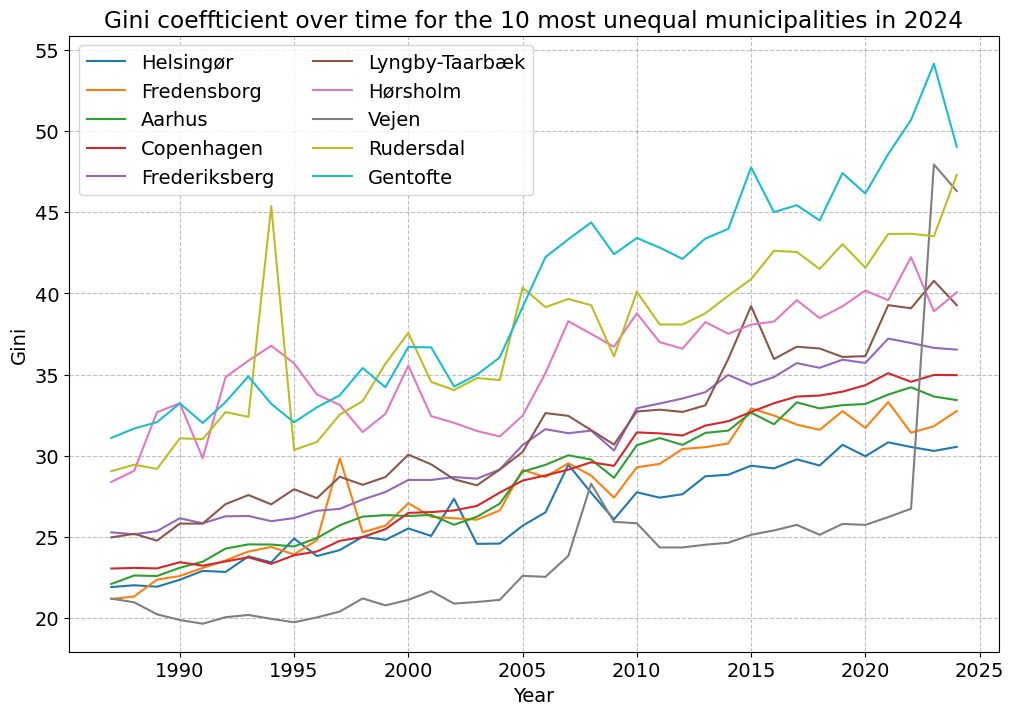

In [30]:
# Plotting the 10 municipalities with the highest Gini in 2024

most_unequal_plot= largest_gini["municipalities"]

fig, ax = plt.subplots(figsize=(12, 8))
for muni in most_unequal_plot:
    series= municip_gini[municip_gini["municipalities"]==muni]["gini"].astype(float)
    ax.plot(series.index, series.values, label=muni)
ax.set_xlabel('Year')
ax.set_ylabel('Gini')
ax.set_title('Gini coeffticient over time for the 10 most unequal municipalities in 2024')
ax.legend(ncol=2)
plt.show()

In [31]:
# Change in Gini coefficient for Vejen
vejen = municip_gini[municip_gini['municipalities'] == 'Vejen']

gini_2023 = float(vejen.loc[2023, 'gini'])
gini_2022 = float(vejen.loc[2022, 'gini'])

difference = gini_2023 - gini_2022

print(f'Gini in 2023: {gini_2023:.3f}')
print(f'Gini in 2022: {gini_2022:.3f}')
print(f'Difference: {difference:.3f}')

Gini in 2023: 47.950
Gini in 2022: 26.740
Difference: 21.210


Also in this case with the ten most unequal municipalities, are the Gini coefficients rising which means the municipalities become more unequal with time. Most of the municipalities are spiking at different times but also here the Gini coefficients are especielly all rising with a fall afterwards because of the financial crisis.
Vejen is here shown as an outlier. According to the calculations above the Gini coefficient for Vejen has risen from 26.74 in 2022 to 47.95 in 2023. That is a difference of 21.21 in one year. A reason for this might be that a single person or a few person in Vejen had a very big change in their income. Vejen is a municipality of almost 43000 citizens according to DST. When a municipality is not larger then a single person can have a big influence on the Gini coefficient.

#### 1.3.3

In [32]:

municip_gini3 = municip_gini.reset_index()
gini_2024 = municip_gini3[municip_gini3['year'] == 2024][['municipalities', 'gini']].rename(columns={'gini': 'gini_2024'})
gini_1987 = municip_gini3[municip_gini3['year'] == 1987][['municipalities', 'gini']].rename(columns={'gini': 'gini_1987'})

gini_change = gini_2024.merge(gini_1987, on='municipalities', how='inner')


gini_change['gini_change'] = gini_change['gini_2024'].astype(float) - gini_change['gini_1987'].astype(float)

gini_change_sorted = gini_change.sort_values('gini_change', ascending=False)


# Biggest change
print("Biggest change in Gini: ")
print(gini_change_sorted.head(10))

# Smallest change
print("Smallest change in Gini: ")
print(gini_change.sort_values('gini_change', ascending=True).head(10))

Biggest change in Gini: 
    municipalities gini_2024 gini_1987  gini_change
7            Vejen     46.32     21.20        25.12
74       Rudersdal     47.31     29.05        18.26
64        Gentofte     49.04     31.10        17.94
57  Lyngby-Taarbæk     39.28     24.97        14.31
69      Copenhagen     34.97     23.05        11.92
73        Hørsholm     40.07     28.39        11.68
50     Fredensborg     32.76     21.17        11.59
39          Aarhus     33.43     22.10        11.33
68   Frederiksberg     36.54     25.28        11.26
53      Vallensbæk     26.70     15.90        10.80
Smallest change in Gini: 
     municipalities gini_2024 gini_1987  gini_change
9              Fanø     26.34     25.67         0.67
15              Ærø     26.98     24.63         2.35
97             Faxe     24.09     21.64         2.45
28             Læsø     25.41     22.81         2.60
75         Bornholm     24.03     21.31         2.72
48  Faaborg-Midtfyn     23.77     20.88         2.89
81    

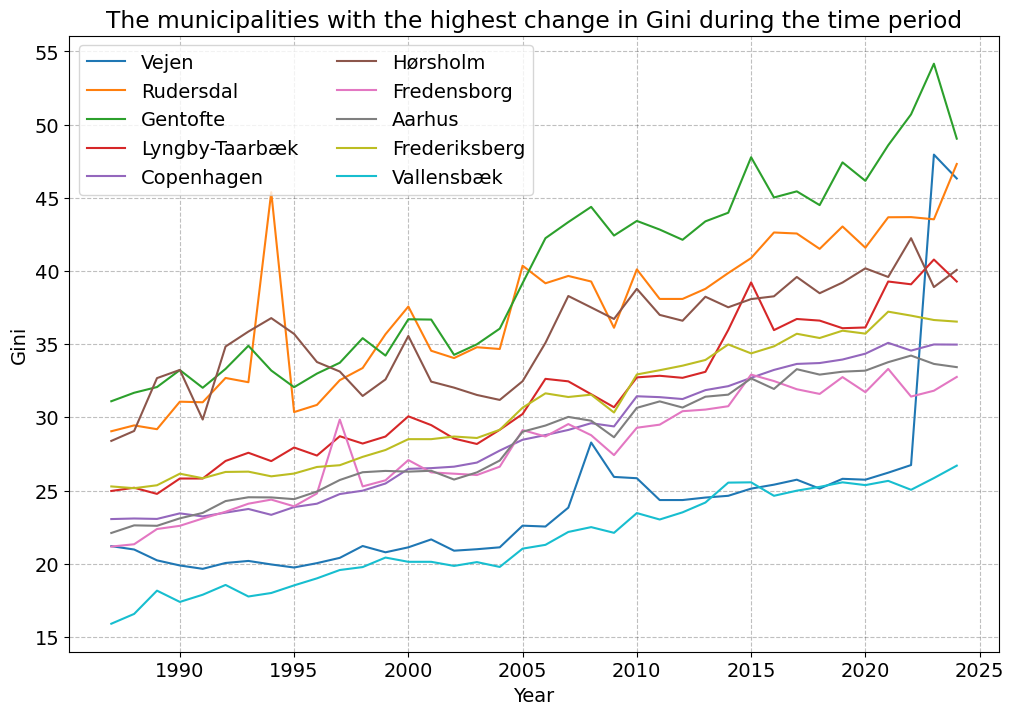

In [33]:
# Plotting the 10 municipalities with the biggest change in Gini during the period

biggest_change_gini = gini_change_sorted.head(10)

biggets_change_plot= biggest_change_gini["municipalities"]

fig, ax = plt.subplots(figsize=(12, 8))
for muni in biggets_change_plot:
    series= municip_gini[municip_gini["municipalities"]==muni]["gini"].astype(float)
    ax.plot(series.index, series.values, label=muni)
ax.set_xlabel('Year')
ax.set_ylabel('Gini')
ax.set_title('The municipalities with the highest change in Gini during the time period')
ax.legend(ncol=2)
plt.show()

##### The 10 municipalities with the highest change in Gini during the period

The plot above shows the 10 municipalities in Denmark who had the highest absoloute change in Gini coefficient from 1987-2024. The municipality with the highest abselutte change is Vejen, where we see an increase in Gini of 25.12. The Gini coefficient in Vejen has thus more than doubled from 1987 to 2024. However, if we look at the plot above, we can tell that the majority of this change is due to a high sudden increase of arrounf 20 in gini from 2022 to 2023. The change in Gini in Vejen from 1987-2022 is arround 5. Vejen being on the list of the 10 municipalitise with the highest change in Gini during the time period is thus pretty much manly driven by the high increa in 2023. 

Another municipality on the plot with a high sudden increase is Rudersdal. Rudersdal has a increase in Gini of 18.26 from 1987 to 2024. This increase is thus mainly driven by a sudden increas of arround 13 from 1993 to 1994.

Theese two examples thus underlines the importance of analysing the underlying development in gini during the period as major outliers quickly can make the underlying change appear larger and more structural than they actually are.
Vejen and Rudersdahl aren´t the only municipalities experiencing spikes in Gini. This indicates that a big part of the municipalities being a part of the 10 municipalities with the highest change in Gini, is driven by spikes in Gini rather than general tendenzy.

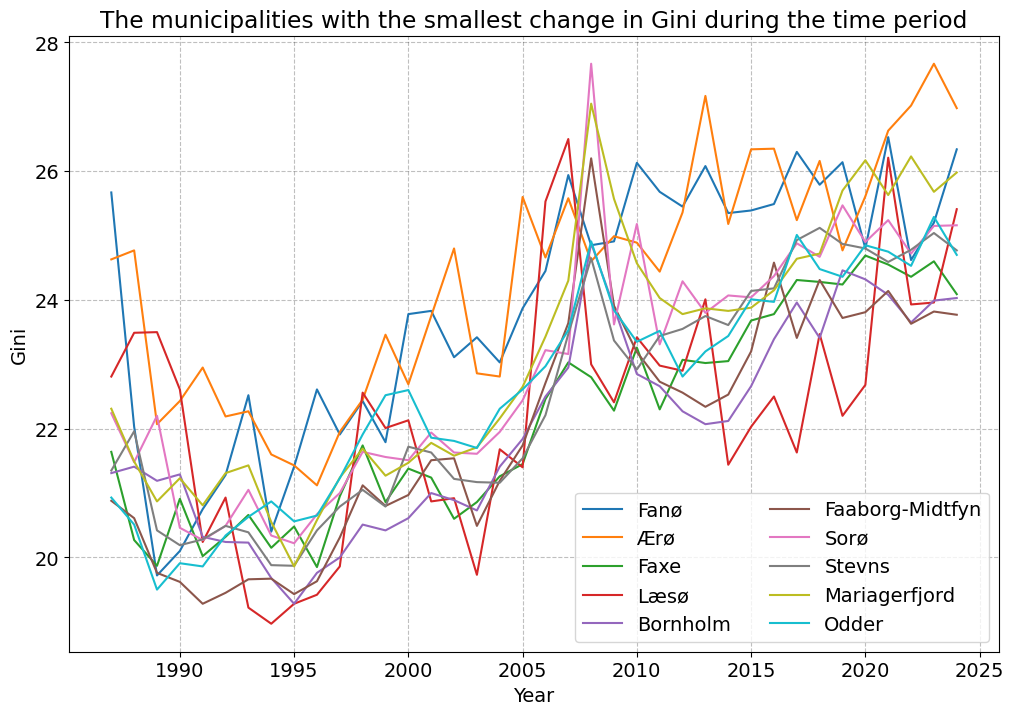

In [34]:
# Plotting the 10 municipalities with the smallest change in Gini during the period

smallest_change_gini = gini_change.sort_values('gini_change', ascending=True).head(10)

smallest_change_plot= smallest_change_gini["municipalities"]

fig, ax = plt.subplots(figsize=(12, 8))
for muni in smallest_change_plot:
    series= municip_gini[municip_gini["municipalities"]==muni]["gini"].astype(float)
    ax.plot(series.index, series.values, label=muni)
ax.set_xlabel('Year')
ax.set_ylabel('Gini')
ax.set_title('The municipalities with the smallest change in Gini during the time period')
ax.legend(ncol=2)
plt.show()

##### The 10 municipalities with the smallest change in Gini during the period

The plot above shows the 10 municipalities in Denmark that had the lowest absolute change in Gini coefficient from 1987 to 2024. All of the municipalities have seen an increase in Gini from 1987 to 2024, even though they are the municipalities with the lowest abseloutte change. This indicates that the Gini coefficient in Denmark overall has increased during the time period. However it is important to keep in mind that the absolute changes are highly influenced by the used start and end year as these can vary alot (as we can see on the two plots). Therefore, the absolute changes can be very different depending on the chosen years.

The municipalites with the smallest change in Gini have a lot of fluctuations throughout the years. Most of the municipalities with the smallest change in Gini from 1987 to 2024 are fairly small municipalities. Small municipalities are not robust to a single very large income as it can quickly cause spikes in Gini. A reason for the many spikes in Gini in the small municipalities could thus be explained by for example changes in a few, but very large incomes.

### 1.4 Extension

In this part of the data projet we want to analyse the correlation between the gini coefficient and unemployment.

We want to analyse that by making a scatterplot showing the Gini coefficient against the unenmployment rate across municipalities in 2007 and 2024 (the first and the last year with data in table AUPL01)

A hypotesis could be that municipalities with a high Gini coefficit also has a higher unemployment rate which contributes to making the municipalities more unequal.

In [35]:
# Using table AULP01 for the uenployment rate - importing the data

AULP01 = DstApi('AULP01')

AULP01.tablesummary(language='en')

Table AULP01: Full-time unemployed persons in per cent of the labour force by region, age, sex and time
Last update: 2026-04-14T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,OMRÅDE,117,000,All Denmark,997,Abroad,False
1,ALDER,10,TOT,"Age, total",6099,60 year and over,False
2,KØN,3,TOT,Total,K,Women,False
3,Tid,19,2007,2007,2025,2025,True


In [36]:
# Setting up the table for AULP01

params = {
    'table': 'AULP01',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['*']},
        {'code': 'ALDER', 'values': ['TOT']},
        {'code': 'KØN', 'values': ['TOT']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

unemployment = AULP01.get_data(params=params)
unemployment.head(5)

,OMRÅDE,ALDER,KØN,TID,INDHOLD
0,All Denmark,"Age, total",Total,2013,5.8
1,Province Byen København,"Age, total",Total,2013,6.9
2,Province Københavns omegn,"Age, total",Total,2013,5.9
3,Province Nordsjælland,"Age, total",Total,2013,4.4
4,Province Bornholm,"Age, total",Total,2013,7.0


In [37]:
# Cleaning up the unemployment data

unemployment =unemployment.drop(columns= ['ALDER','KØN'])
unemployment = unemployment.rename(columns={'INDHOLD':'unemployment', 'OMRÅDE':'municipality', 'TID':'year'})
unemployment = unemployment.set_index('year').sort_index()

display(unemployment)

,municipality,unemployment
year,,
2007,Ringsted,3.1
2007,Vejen,1.9
2007,Aabenraa,3.8
2007,Fredericia,3.3
2007,Horsens,2.3
...,...,...
2025,Svendborg,2.9
2025,Odense,3.8
2025,Nyborg,3.2


In [38]:
# Sorting the municipalities in alphabetical order

unemployment = unemployment.reset_index().sort_values(['year', 'municipality']).reset_index(drop=True)
display(unemployment)

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
4,2007,All Denmark,3.6
...,...,...,...
2180,2025,Vejle,2.4
2181,2025,Vesthimmerlands,2.6
2182,2025,Viborg,2.5
2183,2025,Vordingborg,2.9


In [39]:
# Dropping rows

drop_rows = unemployment.municipality.str.contains('Region')
drop_rows |= unemployment.municipality.str.contains('Provience')
drop_rows |= unemployment.municipality.str.contains('All Denmark')
drop_rows |= unemployment.year==2025
unemployment.loc[~drop_rows,:]

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
5,2007,Allerød,1.6
...,...,...,...
2065,2024,Vejle,2.6
2066,2024,Vesthimmerlands,2.9
2067,2024,Viborg,2.7
2068,2024,Vordingborg,3.0


In [40]:
# Saving the result

unemployment =unemployment.loc[drop_rows==False]
unemployment.iloc[:5,:5]

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
5,2007,Allerød,1.6


In [41]:
# Using table IFOR41 for the gini coefficient
# Resetting the index to use for this task

municip_gini4 = municip_gini.reset_index()

display(municip_gini4)

,year,municipalities,gini
0,1987,Hjørring,21.96
1,1987,Greve,18.64
2,1987,Køge,19.52
3,1987,Halsnæs,18.50
4,1987,Roskilde,20.54
...,...,...,...
3757,2024,Greve,26.35
3758,2024,Frederikssund,26.11
3759,2024,Egedal,23.85
3760,2024,Faxe,24.09


In [ ]:
# Dropping rows

#AULP01 only have data from 2007 and foward so we are dropping the rows before that in IFOR41
drop_rows = municip_gini4.year.between(1987,2006)
drop_rows |= municip_gini4.municipalities.str.contains('All Denmark')

municip_gini5 = municip_gini4.loc[~drop_rows,:]
display(municip_gini5)

,year,municipalities,gini
1980,2007,Odsherred,23.21
1981,2007,Egedal,21.07
1982,2007,Frederikssund,23.47
1983,2007,Greve,24.48
1984,2007,Køge,22.85
...,...,...,...
3757,2024,Greve,26.35
3758,2024,Frederikssund,26.11
3759,2024,Egedal,23.85
3760,2024,Faxe,24.09


In [43]:
# Merging the two tables

unemployment2 = unemployment.rename(columns = {'municipality': 'municipalities'})

combined1 = pd.merge(
        unemployment2.reset_index(drop=True),
        municip_gini5.reset_index(drop=True),
        on= ['year', 'municipalities'],
        how= 'inner'
)

combined =combined.sort_values(['municipalities','year']).reset_index(drop=True)

display(combined1)

,year,municipalities,unemployment,gini
0,2007,Aabenraa,3.8,25.36
1,2007,Aalborg,5.1,26.07
2,2007,Aarhus,3.9,30.03
3,2007,Albertslund,4.8,23.34
4,2007,Allerød,1.6,25.00
...,...,...,...,...
1759,2024,Vejle,2.6,27.78
1760,2024,Vesthimmerlands,2.9,26.40
1761,2024,Viborg,2.7,26.07
1762,2024,Vordingborg,3.0,25.84


In [44]:
# Setting up the type

combined1['unemployment'] = combined1['unemployment'].astype(float)
combined1['gini'] = combined1['gini'].astype(float)

#### Showing the results for 2007

In [66]:
# Sorting Gini values for 2007
gini_2007 = municip_gini.loc[2007].sort_values('gini')

# Finding the smallest and largest Gini coefficients
smallest_gini = gini_2007[['municipalities', 'gini']].head(10)
largest_gini = gini_2007[['municipalities', 'gini']].tail(10)

print('10 most equal municipalities')
print(smallest_gini)

print('10 most unequal municipalities')
print(largest_gini)

10 most equal municipalities
     municipalities   gini
year                      
2007         Egedal  21.07
2007         Tårnby  21.58
2007        Halsnæs  21.58
2007        Rødovre  21.94
2007        Brøndby  22.01
2007     Vallensbæk  22.17
2007          Ishøj  22.45
2007       Glostrup  22.46
2007       Hvidovre  22.51
2007      Hedensted  22.73
10 most unequal municipalities
      municipalities   gini
year                       
2007          Lemvig  28.56
2007      Copenhagen  29.14
2007       Helsingør  29.45
2007     Fredensborg  29.54
2007          Aarhus  30.03
2007   Frederiksberg  31.39
2007  Lyngby-Taarbæk  32.46
2007        Hørsholm  38.29
2007       Rudersdal  39.66
2007        Gentofte  43.34


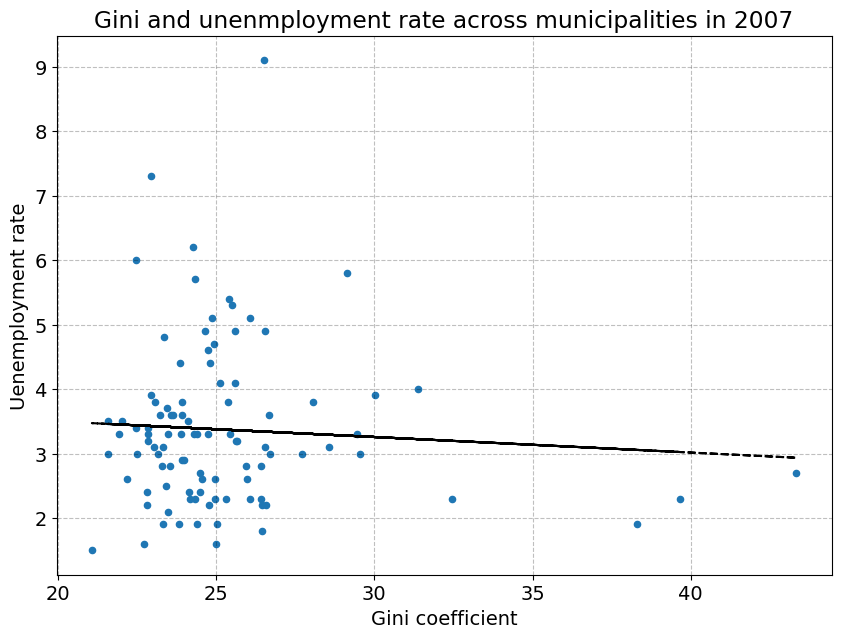

In [65]:
# Makking a scatterplot for 2007

combined1_2007 = combined1[combined1['year'] == 2007]

fig = plt.figure(figsize = (10,7))
ax=fig.add_subplot(1,1,1)
ax.scatter(combined1_2007["gini"],combined1_2007["unemployment"], s=20)

ax.set_title("Gini and unenmployment rate across municipalities in 2007")
ax.set_xlabel('Gini coefficient')
ax.set_ylabel('Uenemployment rate');

# Adding a trendline
z = np.polyfit(combined1_2007["gini"], combined1_2007["unemployment"], 1)
p = np.poly1d(z)
ax.plot(combined1_2007["gini"],p(combined1_2007["gini"]),color='black',ls='--',label='trendline')

#### Analysing the results from 2007

The scatterplot shows the Gini coefficient against the unenmployment rate across municipalities in 2007.The data shows a weak slightly negative relationship between Gini and the unemployment rate. This is the oposite of the hypothesis that a higher unemploymentrate is connected with higher inequality. The majority of the municipalities cluster arround a Gini range of 21-27 and unemployment between 2-4%. The biggest outlier in 2007 is Læsø which has a Gini coeffecient arround 25 but an uemployment rate of 9.1%. Læsø is a really small municipality which can result in a number of people loosing their job quickly having a big impact on the uenmployment rate. The three most unequal municipalities in 2007 - Gentofte, Rudersdal and Hørsholm - all has a unemployment rate around 2-2.5%. This is well below the national average in 2007. Therefore this further weakness the hypothesis about a positive correlation between unemployment and inequality.


#### Showing the results for 2024

In [67]:
# Sorting Gini values for 2024
gini_2024 = municip_gini.loc[2024].sort_values('gini')

# Finding the smallest and largest Gini coefficients
smallest_gini = gini_2024[['municipalities', 'gini']].head(10)
largest_gini = gini_2024[['municipalities', 'gini']].tail(10)

print('10 most equal municipalities')
print(smallest_gini)

print('10 most unequal municipalities')
print(largest_gini)

10 most equal municipalities
       municipalities   gini
year                        
2024  Faaborg-Midtfyn  23.77
2024           Egedal  23.85
2024         Bornholm  24.03
2024             Faxe  24.09
2024         Favrskov  24.41
2024          Halsnæs  24.41
2024           Assens  24.46
2024        Hedensted  24.58
2024      Albertslund  24.66
2024            Odder  24.70
10 most unequal municipalities
      municipalities   gini
year                       
2024       Helsingør  30.55
2024     Fredensborg  32.76
2024          Aarhus  33.43
2024      Copenhagen  34.97
2024   Frederiksberg  36.54
2024  Lyngby-Taarbæk  39.28
2024        Hørsholm  40.07
2024           Vejen  46.32
2024       Rudersdal  47.31
2024        Gentofte  49.04


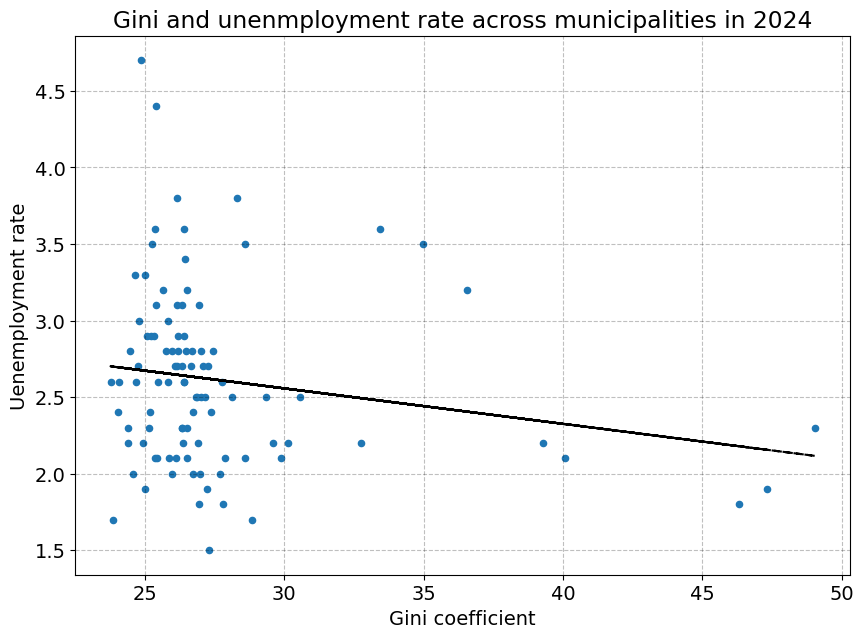

In [64]:
# Makking a scatterplot for 2024

combined1_2024 = combined1[combined1['year'] == 2024]

fig = plt.figure(figsize = (10,7))
ax=fig.add_subplot(1,1,1)
ax.scatter(combined1_2024["gini"],combined1_2024["unemployment"], s=20)

ax.set_title("Gini and unenmployment rate across municipalities in 2024")
ax.set_xlabel('Gini coefficient')
ax.set_ylabel('Uenemployment rate');

# Adding a trendline
z = np.polyfit(combined1_2024["gini"], combined1_2024["unemployment"], 1)
p = np.poly1d(z)
ax.plot(combined1_2024["gini"],p(combined1_2024["gini"]),color='black',ls='--',label='trendline')


#### Analysing the results from 2024

The scatterplot shows the Gini coefficient against the unenmployment rate across municipalities in 2024. By 2024 we see rise in the average Gini coefficient. However, the relationship between unemployment and inequality is still slightly negative. The majority of the municipalities now cluster arround a Gini range of 25-30 and unemployment between 2-3%. 

The three most unequal municipalities in 2024 - Gentofte, Rudersdal and Vejen - all have an unemployment rate around 1.8-2.3%. However, we dont´t put much weigh on Vejen being the municipality with the third highest Gini coefficient in 2024, since we showed in taskt 1.3.3 that Vejen experienced a major outlier that year.
This suggests that the most unequal municipalities are wealthy Copenhagen-surburbs where a high Gini coefficient reflect a high concentration of people with high income and not a high unemployment rate.


#### Overall conclusion

Across both 2007 and 2024 the data shows that a higher unemployment rate does not go hand in hand with a higher gini coefficient - if anything the opposite the is sligthly the case. The most unequal municipalities in Denmark are wealthy Copenhagen surburbs, where a high Gini coefficient reflects a high concentration of people with high income rather than a high unemployment rate.

This lack of coherrence between unemployment and inequality could be in linked to the danish welfare system and its broad social safety net. People who becomes unemployd in Denmark, for example, has the posibility of recieving dagpenge. Therefore, this is likely to dampen the corelation wich otherwise could have existed between uenmployment and inequality. 
However, it is important to keep in mind that unemployment and Gini relates to two different things. Uenmployment refelcts the labour market at a given point in time whereas Gini reflects the entire income distribution.

<h2> 2 Simulating the income distribution

### 2.1 The model

In [50]:
import pickle
import numpy as np

from scipy.stats import norm 

In [51]:
from income_simulation import simulate_income_distribution
from Gini import gini
import numpy as np

N=50000
p_e=(0.4,0.35,0.25)
s_e=(1,3,5)
h_e0=(1.00,1.20,1.55)
delta_e=(0.010,0.020,0.030)
delta=(0.06)
sigma_psi=0.1
lambda_psi=0.6
sigma=0.05
y_su=0.45
rho=0.60
y_floor=0.35
age_min=18
age_max=65
seed=123

result = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)


ages = result['ages']
income = result['income']      
employed = result['employed']
e = result['education']

print(result) ##need to make prettier

#Check that the mean is one for the lognormal shock psi
rng_check = np.random.default_rng(seed)
psi_check = rng_check.lognormal(-0.5 * sigma_psi**2, sigma_psi, size=1_000_000)

print(f'Mean of psi: {psi_check.mean():.4f}')  # should be equal or close to 1.0

Mean of psi: 1.0001
{'ages': array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]), 'income': array([[0.45      , 0.45      , 0.45      , ..., 0.78061543, 0.75954873,
        0.8253255 ],
       [0.45      , 0.35      , 0.83498012, ..., 0.42095175, 0.43441942,
        0.42650798],
       [0.45      , 0.35      , 0.35      , ..., 0.7605678 , 0.92393649,
        1.05218231],
       ...,
       [0.45      , 0.45      , 0.45      , ..., 2.51647246, 2.07051497,
        2.00609383],
       [0.45      , 0.45      , 0.45      , ..., 2.44713031, 2.71745258,
        2.88679451],
       [0.45      , 0.35      , 1.09286273, ..., 2.81507515, 3.18277143,
        2.88798228]], shape=(50000, 48)), 'employed': array([[False, False, False, ...,  True,  True,  True],
       [False, False,  True, ...,  True,  True,  True],
       [False, False, Fal

### 2.2 Simulate the income distribution

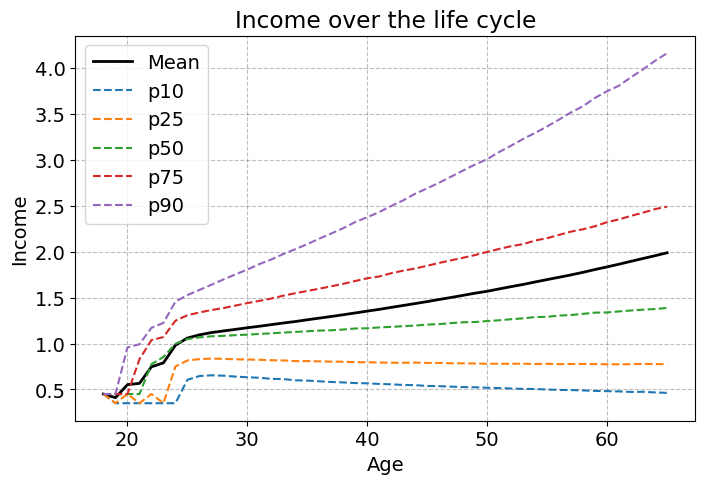

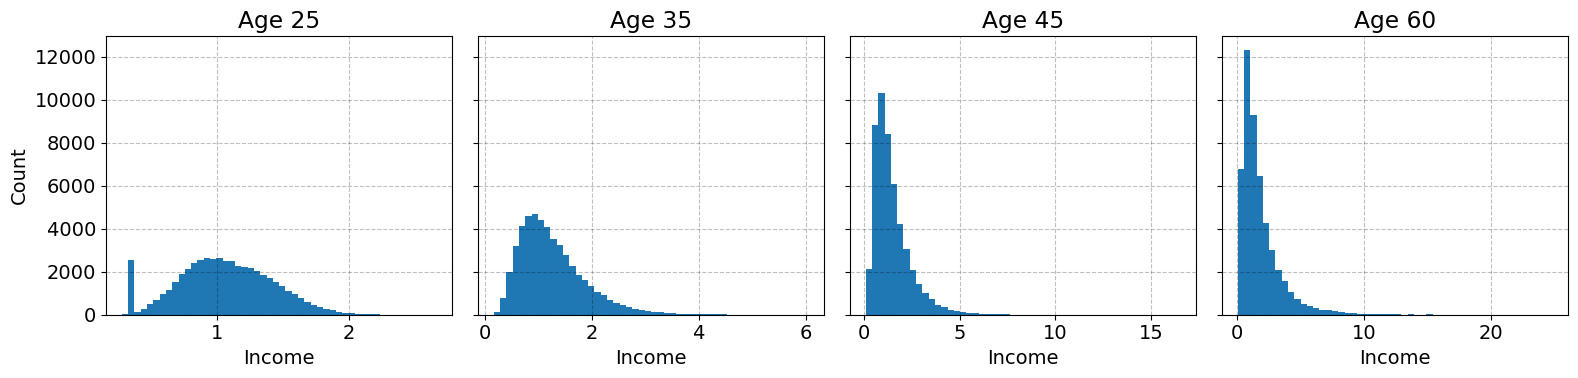

In [52]:

#Mean and selected percentiles of income over the life cycle

percentiles = [10, 25, 50, 75, 90]
income_percentiles = np.percentile(income, percentiles, axis=0)  # shape (5, T)
income_mean = income.mean(axis=0)

#life cycle of income plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ages, income_mean, label='Mean', linewidth=2, color='black')
for p, series in zip(percentiles, income_percentiles):
    ax.plot(ages, series, label=f'p{p}', linestyle='--')
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_title('Income over the life cycle')
ax.legend()
plt.show()

#Income distribution histogram
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, age in zip(axes, [25, 35, 45, 60]):
    idx = age - age_min  # column index for this age
    ax.hist(income[:, idx], bins=50)
    ax.set_title(f'Age {age}')
    ax.set_xlabel('Income')
axes[0].set_ylabel('Count')
fig.tight_layout()
plt.show()



### 2.3 Compute the Gini coefficient

Uniform [0,1] test:   Gini = 0.3334   (target: 0.3333)
Lognormal(s=0.8) test: Gini = 0.4283   (target: 0.4284)


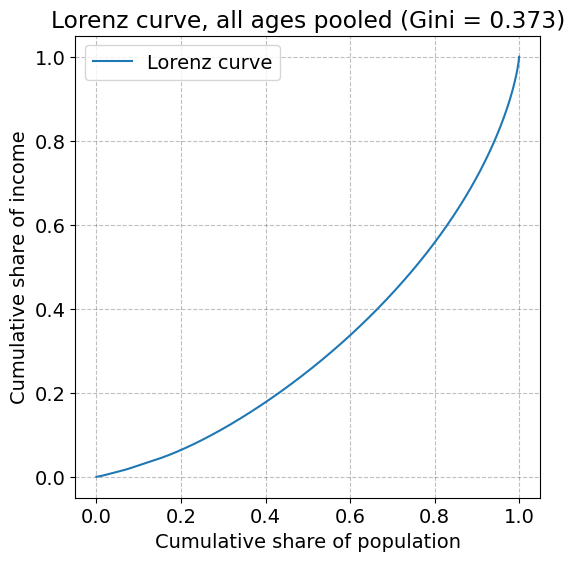

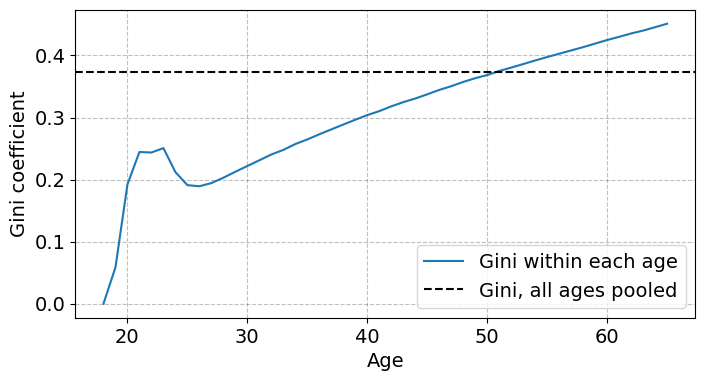

In [53]:
from Gini import gini #gini module
from scipy.stats import norm #normal distribution

#Test 1 with a known Gini coefficient of 1/3
test_rng = np.random.default_rng(0)
u = test_rng.uniform(0, 1, 1_000_000)
uniform_gini = gini(u)
print(f'Uniform [0,1] test:   Gini = {uniform_gini:.4f}   (target: {1/3:.4f})')

#Test 2 with std s and a known Gini coefficient of 2*Phi(s/sqrt(2)) - 1
s_test = 0.8
x_test = test_rng.lognormal(0, s_test, 1_000_000)
lognormal_gini = gini(x_test)
lognormal_target = 2 * norm.cdf(s_test / np.sqrt(2)) - 1
print(f'Lognormal(s={s_test}) test: Gini = {lognormal_gini:.4f}   (target: {lognormal_target:.4f})')

# pooled incomes across all simulated individuals and ages
pooled_income = income.ravel()
pooled_gini = gini(pooled_income)

#calculate cumulative values for Lorenz curve
def lorenz_curve(x):
    x_sorted = np.sort(x)
    cum_income = np.cumsum(x_sorted)
    cum_income_share = cum_income / cum_income[-1]
    cum_pop_share = np.arange(1, len(x) + 1) / len(x)
    return np.insert(cum_pop_share, 0, 0), np.insert(cum_income_share, 0, 0)

pop_share, inc_share = lorenz_curve(pooled_income)

#plot Lorenz curve
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(pop_share, inc_share, label='Lorenz curve')
ax.set_xlabel('Cumulative share of population')
ax.set_ylabel('Cumulative share of income')
ax.set_title(f'Lorenz curve, all ages pooled (Gini = {pooled_gini:.3f})')
ax.legend()
plt.show()

#Gini by age
gini_by_age = np.array([gini(income[:, t]) for t in range(len(ages))])

#plot different ages
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ages, gini_by_age, label='Gini within each age')
ax.axhline(pooled_gini, color='black', linestyle='--', label='Gini, all ages pooled')
ax.set_xlabel('Age')
ax.set_ylabel('Gini coefficient')
ax.legend()

Pooling ages together smooths the curve but overrepresents inequality by not holding age as a variable constant: pooled data is comparing younger, much lower-income earning groups with higher-earning older groups.

### 2.4 What drives inequality?

#### No education inequality
The inequality if everyone get´s a short education:

Mean of psi: 1.0001
The Gini coefficient for all ages pooled is: 0.2955636357548791


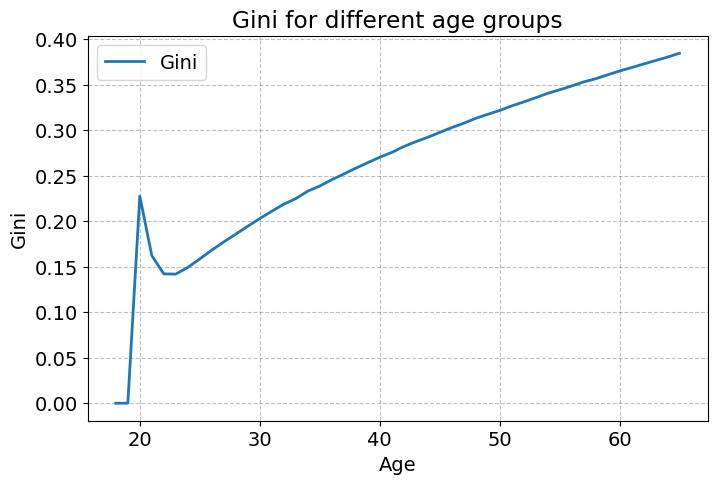

array([-2.11927626e-16,  0.00000000e+00,  2.27545892e-01,  1.62224364e-01,
        1.42115016e-01,  1.41907348e-01,  1.49249046e-01,  1.58602191e-01,
        1.68244878e-01,  1.77275471e-01,  1.85838795e-01,  1.94487531e-01,
        2.02933222e-01,  2.10943393e-01,  2.18725566e-01,  2.24811316e-01,
        2.33026259e-01,  2.38654254e-01,  2.45598830e-01,  2.51828773e-01,
        2.58266636e-01,  2.64324116e-01,  2.70298060e-01,  2.75560214e-01,
        2.82027016e-01,  2.87354227e-01,  2.92203083e-01,  2.97546500e-01,
        3.02877229e-01,  3.07627898e-01,  3.13047423e-01,  3.17444498e-01,
        3.21711274e-01,  3.26668016e-01,  3.31098438e-01,  3.35682308e-01,
        3.40473962e-01,  3.44459322e-01,  3.48554464e-01,  3.53075993e-01,
        3.56577380e-01,  3.60837266e-01,  3.65084013e-01,  3.68820345e-01,
        3.72763699e-01,  3.76577316e-01,  3.80359743e-01,  3.84643332e-01])

In [54]:
from Gini import gini

result_no_education_inequality = simulate_income_distribution(N, (1.0,0.0,0.0), s_e, h_e0, delta_e, delta, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_no_education_inequality = result_no_education_inequality['income']

def unwrap(x):
    unwraped= []
    for array in x:
        for element in array:
            unwraped.append(element)
    return unwraped

def incomeAtAge(income, age):
    atAge= []
    for array in income:
       atAge.append(array[age-age_min])
    return atAge


print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_no_education_inequality)))

def Gini_aged(switched_off_income, plot=True, ax=None, label=None):
    """ Gini coefficient at each age. Adding if statement to allow Gin_aged tto be used in a larger plot and as a table 
    """
    agedGini = np.array([gini(incomeAtAge(switched_off_income, age)) for age in ages])

    if plot:
        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(ages, agedGini, linewidth=2, label=label if label else 'Gini')
        ax.set_xlabel('Age')
        ax.set_ylabel('Gini')
        ax.set_title('Gini for different age groups')
        ax.legend()
        if standalone:
            plt.show()

    return agedGini

Gini_aged(income_no_education_inequality)

#### No shock to human capital

Mean of psi: 1.0000
The Gini coefficient for all ages pooled is: 0.2736059135148775


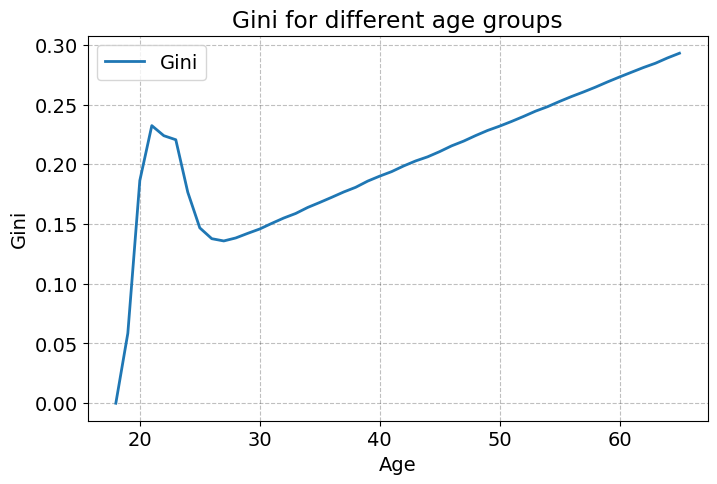

array([-2.11927626e-16,  5.85403680e-02,  1.86394212e-01,  2.32362312e-01,
        2.23931867e-01,  2.20555795e-01,  1.76581158e-01,  1.46788833e-01,
        1.37724696e-01,  1.35837055e-01,  1.38339541e-01,  1.42195201e-01,
        1.45846581e-01,  1.50535697e-01,  1.55010856e-01,  1.58840363e-01,
        1.63872041e-01,  1.68035826e-01,  1.72354203e-01,  1.76812622e-01,
        1.80744978e-01,  1.85911808e-01,  1.90076503e-01,  1.93869125e-01,
        1.98608044e-01,  2.02797056e-01,  2.06246428e-01,  2.10598658e-01,
        2.15433171e-01,  2.19388850e-01,  2.24026119e-01,  2.28318638e-01,
        2.31927795e-01,  2.35871029e-01,  2.40071931e-01,  2.44493742e-01,
        2.48224492e-01,  2.52605329e-01,  2.56732451e-01,  2.60555851e-01,
        2.64596537e-01,  2.68952550e-01,  2.73077352e-01,  2.77055077e-01,
        2.81015893e-01,  2.84601065e-01,  2.89024540e-01,  2.92969809e-01])

In [55]:
result_no_shock = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, 0.0,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_no_shock = result_no_shock['income']

print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_no_shock)))

Gini_aged(income_no_shock)

#### Depreciation of human capital while unemployed

Mean of psi: 1.0001
The Gini coefficient for all ages pooled is: 0.37980741075126667


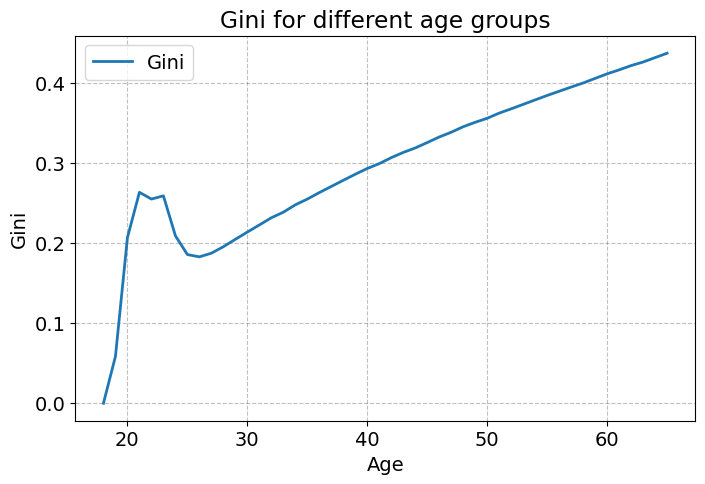

array([-2.11927626e-16,  5.85403680e-02,  2.07070291e-01,  2.63548511e-01,
        2.55126521e-01,  2.59133128e-01,  2.09225827e-01,  1.85755837e-01,
        1.82925905e-01,  1.87465498e-01,  1.95585478e-01,  2.04839061e-01,
        2.13876358e-01,  2.22779004e-01,  2.31758916e-01,  2.38728710e-01,
        2.47930759e-01,  2.55106458e-01,  2.63223305e-01,  2.70880975e-01,
        2.78568544e-01,  2.86142834e-01,  2.93350733e-01,  2.99400281e-01,
        3.06857959e-01,  3.13382592e-01,  3.18981238e-01,  3.25730502e-01,
        3.32698191e-01,  3.38619879e-01,  3.45512207e-01,  3.51079628e-01,
        3.56070046e-01,  3.62533665e-01,  3.67875254e-01,  3.73459935e-01,
        3.79046148e-01,  3.84580941e-01,  3.89847723e-01,  3.95068403e-01,
        4.00175403e-01,  4.05902853e-01,  4.11601067e-01,  4.16568150e-01,
        4.21910882e-01,  4.26364126e-01,  4.31879721e-01,  4.37362526e-01])

In [56]:
result_human_capital = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, 0.0, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_human_capital = result_human_capital['income']

print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_human_capital)))

Gini_aged(income_human_capital)

#### Unemplyment itself

Mean of psi: 1.0001
The Gini coefficient for all ages pooled is: 0.37685512511680463


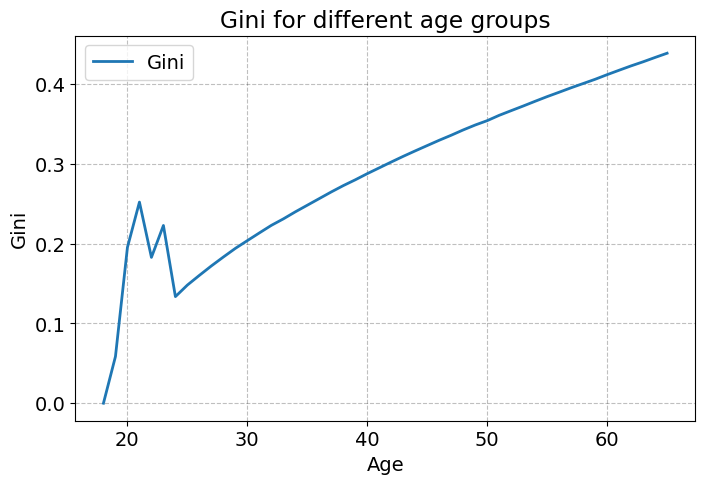

array([-2.11927626e-16,  5.85403680e-02,  1.95400878e-01,  2.52108070e-01,
        1.82820735e-01,  2.22805406e-01,  1.33623914e-01,  1.48135290e-01,
        1.60294891e-01,  1.72122994e-01,  1.83283560e-01,  1.94096996e-01,
        2.03838067e-01,  2.13466026e-01,  2.22944970e-01,  2.31049909e-01,
        2.39897239e-01,  2.48210468e-01,  2.56528908e-01,  2.64860997e-01,
        2.72770197e-01,  2.80051572e-01,  2.87763264e-01,  2.95055495e-01,
        3.02357496e-01,  3.09480794e-01,  3.16318613e-01,  3.22980801e-01,
        3.29634920e-01,  3.35918404e-01,  3.42574468e-01,  3.48729302e-01,
        3.54193895e-01,  3.60870763e-01,  3.66732275e-01,  3.72522271e-01,
        3.78499441e-01,  3.84335316e-01,  3.89829391e-01,  3.95424975e-01,
        4.00720814e-01,  4.06038739e-01,  4.11836945e-01,  4.17385049e-01,
        4.22853580e-01,  4.27955758e-01,  4.33406117e-01,  4.38706116e-01])

In [57]:
result_unemployment = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, sigma_psi,
                                      1.0, 0.0, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_unemployment = result_unemployment['income']

print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_unemployment)))

Gini_aged(income_unemployment)

#### Without any changes in the variables

Mean of psi: 1.0001
The Gini coefficient for all ages pooled is: 0.3727564691326209


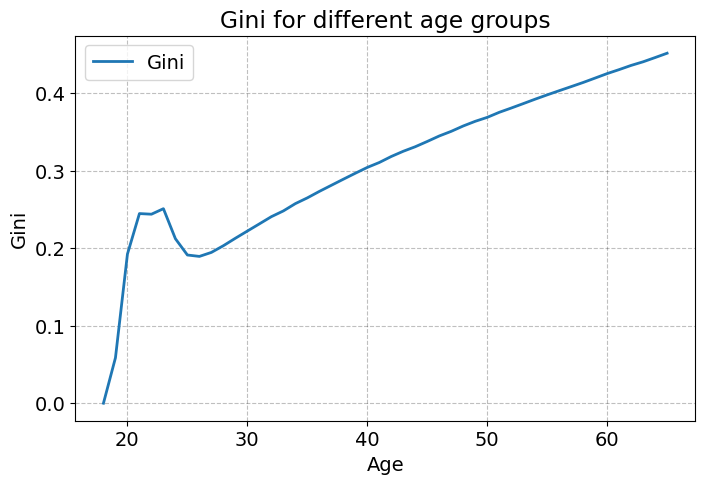

array([-2.11927626e-16,  5.85403680e-02,  1.92272742e-01,  2.44475783e-01,
        2.43661358e-01,  2.50768525e-01,  2.12057880e-01,  1.91071025e-01,
        1.89263606e-01,  1.94420643e-01,  2.03047671e-01,  2.12660821e-01,
        2.21947372e-01,  2.31175605e-01,  2.40473531e-01,  2.47873678e-01,
        2.57290173e-01,  2.64703341e-01,  2.73044675e-01,  2.80900986e-01,
        2.88747779e-01,  2.96451489e-01,  3.03969522e-01,  3.10309504e-01,
        3.18070817e-01,  3.24788834e-01,  3.30646125e-01,  3.37442887e-01,
        3.44506744e-01,  3.50492531e-01,  3.57397901e-01,  3.63409440e-01,
        3.68486511e-01,  3.74988807e-01,  3.80496631e-01,  3.86191738e-01,
        3.91964434e-01,  3.97498437e-01,  4.02853552e-01,  4.08134767e-01,
        4.13469894e-01,  4.19171082e-01,  4.24925830e-01,  4.30054708e-01,
        4.35476823e-01,  4.40133214e-01,  4.45591683e-01,  4.51187311e-01])

In [58]:
result_udg = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_udg = result_udg['income']

print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_udg)))

Gini_aged(income_udg)

Overall the gini coefficient is larger for people in their twenties. A reason for this might be how fast people get a job. The first graph whith no education inequality shows that if everyone got the same education then the inequality would still be large in the beginning but for a shorter timeperiod compared to the other cases where people have different length of education. After the spike in the twenties, then people will become more equal and afterwards less equal again. This trend might come because of growth in human capital which increases more for people with a longer education. The human capital is the same as the income in the model when employed.

,Mechanism,Pooled Gini,Change from baseline,Change from baseline (%)
0,No shock to human capital,0.2736,-0.0992,-26.6%
1,No education inequality,0.2956,-0.0772,-20.7%
2,No depreciation while unemployed,0.3798,+0.0071,+1.9%
3,No unemployment risk,0.3769,+0.0041,+1.1%
4,Baseline (no changes),0.3728,+0.0000,+0.0%


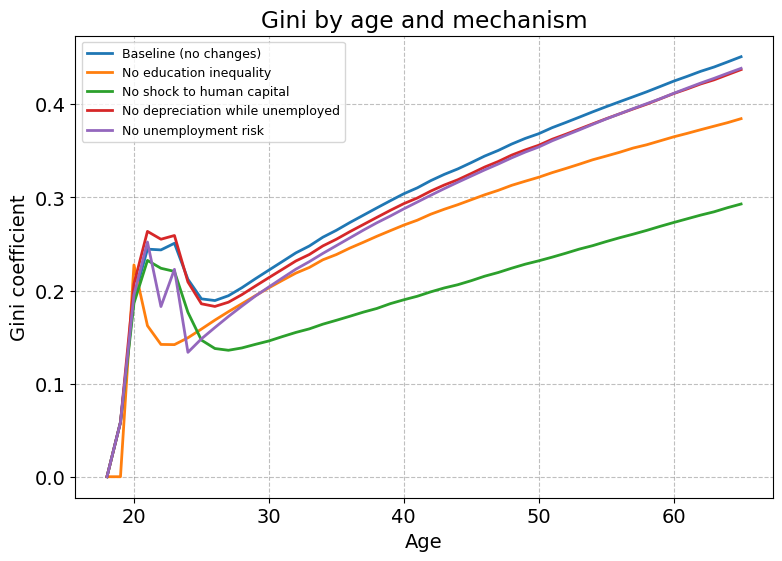

In [59]:
# Summary table and combined comparison plot for the mechanisms above.

mechanisms = {
    'Baseline (no changes)':                income_udg,
    'No education inequality':              income_no_education_inequality,
    'No shock to human capital':            income_no_shock,
    'No depreciation while unemployed':     income_human_capital,
    'No unemployment risk':                 income_unemployment,
}

baseline_gini = gini(unwrap(income_udg))

rows = []
gini_by_age_all = {}
for name, inc in mechanisms.items():
    pooled = gini(unwrap(inc))
    by_age = Gini_aged(inc, plot=False)      
    gini_by_age_all[name] = by_age

    rows.append({
        'Mechanism': name,
        'Pooled Gini': pooled,
        'Change from baseline': pooled - baseline_gini,
        'Change from baseline (%)': (pooled - baseline_gini) / baseline_gini * 100,
    })

summary = pd.DataFrame(rows)
summary['abs_effect'] = summary['Change from baseline'].abs()
summary = summary.sort_values('abs_effect', ascending=False).drop(columns='abs_effect').reset_index(drop=True)

display(summary.style.format({
    'Pooled Gini': '{:.4f}',
    'Change from baseline': '{:+.4f}',
    'Change from baseline (%)': '{:+.1f}%',
}))

# Combined plot: all mechanisms' Gini-by-age curves on one set of axes
fig, ax = plt.subplots(figsize=(9, 6))
for name, by_age in gini_by_age_all.items():
    ax.plot(ages, by_age, linewidth=2, label=name)
ax.set_xlabel('Age')
ax.set_ylabel('Gini coefficient')
ax.set_title('Gini by age and mechanism')
ax.legend(fontsize=9)
plt.show()

#### Which mechanism matters the most?
The mechanism that changes the gini coefficient most significantly is the second experiment "No shock to human capital" which changes the Gini 26.6% from the pooled baseline of 0.3728 to 0.2736. In this model, human capital shocks have the largest impact on inequality. 

The first experiment "No education inequality" made the gini coefficient smaller to 0.2956 and therefore society became more equal.  The third experiment "No depreciation of human capital while unemployed" increased the gini coefficient to 0.3798, increasing inequality.The fourth experiment also increased inequality and resulted in a Gini coefficient of 0.3769


### 2.5 Extension: Disability risk

In [60]:
"""
If something happens, so you cannot work anymore, then you can get a disability pension, y_dis, where your income then will be y_dis=0.6
The probability of becoming disabled is p_dis=0.02
"""
from income_simulation_disabled import simulate_income_distribution_disabled

N=50000
p_e=(0.4,0.35,0.25)
s_e=(1,3,5)
h_e0=(1.00,1.20,1.55)
delta_e=(0.010,0.020,0.030)
delta=(0.06)
sigma_psi=0.1
lambda_psi=0.6
sigma=0.05
y_su=0.45
rho=0.60
y_floor=0.35
age_min=18
age_max=65
seed=123
y_dis=0.6
p_dis=0.02


result_ext = simulate_income_distribution_disabled(N, p_e, s_e, h_e0, delta_e, delta, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed, y_dis, p_dis)


ages_ext = result_ext['ages']
income_ext = result_ext['income']      
employed_ext = result_ext['employed']
e_ext = result_ext['education']

#### Income distribution and life-cycle projections accounting for disability risk

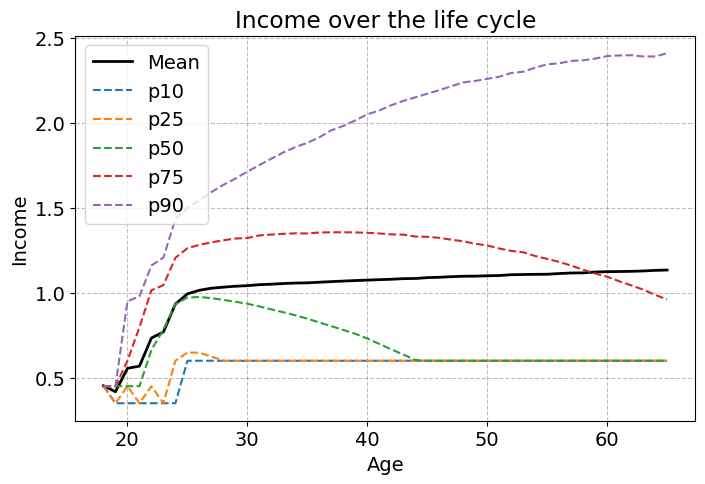

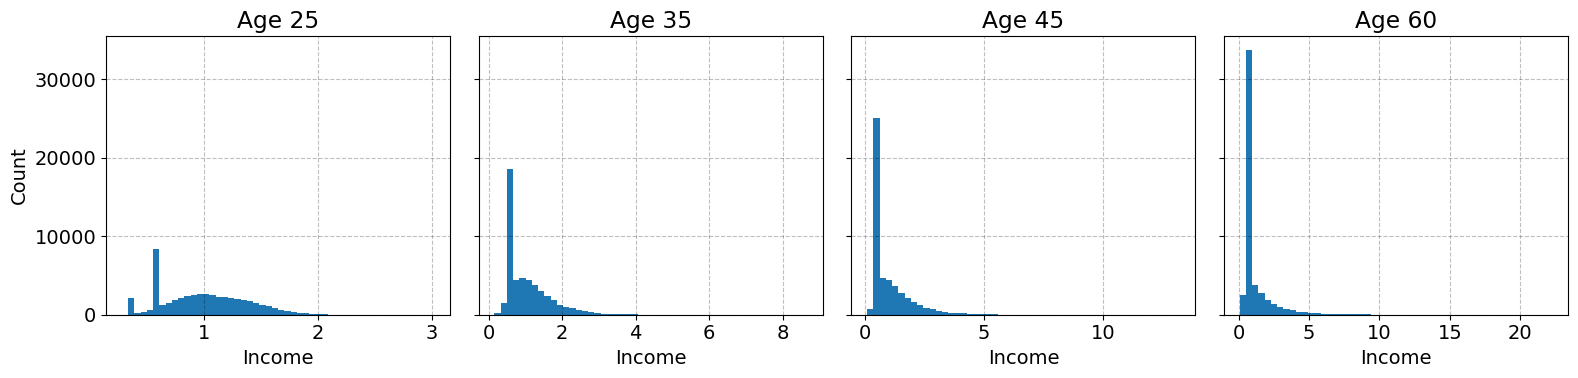

In [61]:
# Mean and selected percentiles of income over the life cycle

percentiles_ext = [10, 25, 50, 75, 90]
income_percentiles_ext = np.percentile(income_ext, percentiles_ext, axis=0)  # shape (5, T)
income_mean_ext = income_ext.mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ages_ext, income_mean_ext, label='Mean', linewidth=2, color='black')
for p, series in zip(percentiles_ext, income_percentiles_ext):
    ax.plot(ages_ext, series, label=f'p{p}', linestyle='--')
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_title('Income over the life cycle')
ax.legend()
plt.show()

# Histograms of the income distribution at selected ages
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, age in zip(axes, [25, 35, 45, 60]):
    idx = age - age_min  # column index for this age
    ax.hist(income_ext[:, idx], bins=50)
    ax.set_title(f'Age {age}')
    ax.set_xlabel('Income')
axes[0].set_ylabel('Count')
fig.tight_layout()
plt.show()

Pooled Gini without disability risk: 0.3728
Pooled Gini with disability risk:    0.3493
Change: -0.0234  (-6.3%)


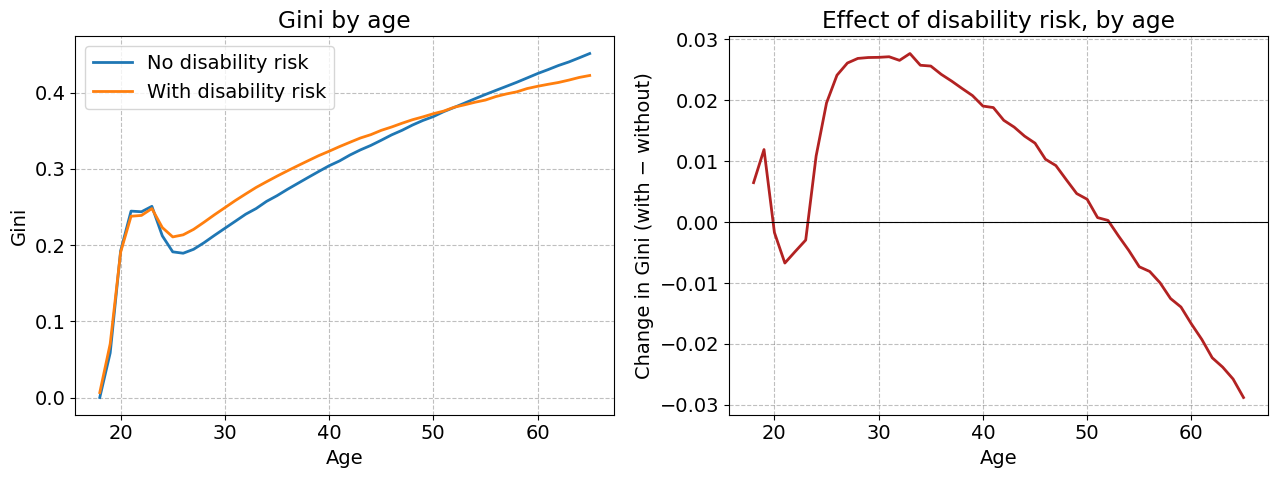

Largest increase in Gini at age 33: +0.0277
Largest decrease in Gini at age 65: -0.0288
Average change in Gini across all ages: +0.0068


In [62]:
# Quantifying how much disability risk changes the Gini coefficient.

gini_baseline_pooled = gini(unwrap(income_udg))   # section 2.4 baseline, no disability risk
gini_ext_pooled      = gini(unwrap(income_ext))   # section 2.5, with disability risk

change_abs = gini_ext_pooled - gini_baseline_pooled
change_pct = change_abs / gini_baseline_pooled * 100

print(f"Pooled Gini without disability risk: {gini_baseline_pooled:.4f}")
print(f"Pooled Gini with disability risk:    {gini_ext_pooled:.4f}")
print(f"Change: {change_abs:+.4f}  ({change_pct:+.1f}%)")

gini_by_age_baseline = Gini_aged(income_udg, plot=False)
gini_by_age_ext      = Gini_aged(income_ext, plot=False)
gini_diff_by_age = gini_by_age_ext - gini_by_age_baseline

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ages, gini_by_age_baseline, label='No disability risk', linewidth=2)
axes[0].plot(ages, gini_by_age_ext, label='With disability risk', linewidth=2)
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Gini'); axes[0].set_title('Gini by age')
axes[0].legend()

axes[1].plot(ages, gini_diff_by_age, color='firebrick', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Change in Gini (with − without)')
axes[1].set_title('Effect of disability risk, by age')

fig.tight_layout()
plt.show()

max_increase_age = ages[np.argmax(gini_diff_by_age)]
print(f"Largest increase in Gini at age {max_increase_age}: +{gini_diff_by_age.max():.4f}")
max_decrease_age = ages[np.argmin(gini_diff_by_age)]
print(f"Largest decrease in Gini at age {max_decrease_age}: {gini_diff_by_age.min():.4f}")
print(f"Average change in Gini across all ages: {gini_diff_by_age.mean():+.4f}")

#### How does the extension change the Gini coefficient?

Adding disability risk lowers the pooled Gini from 0.3728 to 0.3493 (a 6.3% decrease) overall, but the impact on Gini is positive for younger workers and decreases over time; pooling the Gini measures both in-group and across-group inequalities. For within-age group comparisons, the largest per-age effect increase is at age 33 (0.0277), and the largest per-age effect decrease is at age 65, the last value in the range. These extremes are still higher in absolute value than the pooled Gini average, but the mean is only a 0.68% increase. 
